# Practicum 3 - Neural Networks met AmesHousing

In deze notebook bouwen we een neural network om `SalePrice` te voorspellen met de AmesHousing dataset.

Onderzoeksvragen:

- Welke features geven de beste voorspellingen?
- Zijn alle features beter dan een kleinere subset?
- Wat gebeurt er als we learning rate, epochs, validation size en 1/2/3 hidden layers aanpassen?

De code gebruikt dezelfde stijl als de eerdere practica: eerst feature-sets/configuraties definieren, daarna een loop over alle experimenten, en tot slot een samenvattingstabel en grafieken.


In [ ]:
# Imports: data handling, plotting, sklearn models and preprocessing
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Suppress warnings about models not converging within max_iter
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Global constants
RANDOM_STATE = 42
DATA_FILE = Path("AmesHousing.xlsx")
LOG_FILE = Path("experiment_log.xlsx")

pd.set_option("display.max_columns", 100)


## 1. Data laden

De dataset staat in dezelfde map als deze notebook. We voorspellen `SalePrice`; `ID` gebruiken we niet als feature omdat dit alleen een rij-identificatie is.

In [ ]:
# Load the dataset from Excel and show the first rows and column types
df = pd.read_excel(DATA_FILE)

print("Shape:", df.shape)
display(df.head())
display(df.dtypes.to_frame("dtype"))


Shape: (2930, 12)


,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,NAmes,1Story
1,2,105000,yes,5,896,882.0,11622,1961,1,2,NAmes,1Story
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,NAmes,1Story
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,NAmes,1Story
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,Gilbert,2Story


,dtype
ID,int64
SalePrice,int64
Garage,str
Overall Qual,int64
Gr Liv Area,int64
Total Bsmt SF,float64
Lot Area,int64
Year Built,int64
Full Bath,int64
Bedroom AbvGr,int64


In [ ]:
TARGET = "SalePrice"
DROP_COLUMNS = ["ID", TARGET]

# Separate numeric and categorical feature names (excluding ID and target)
numeric_columns = df.drop(columns=DROP_COLUMNS, errors="ignore").select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.drop(columns=DROP_COLUMNS, errors="ignore").select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features:", numeric_columns)
print("Categorical features:", categorical_columns)


Numeric features: ['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Lot Area', 'Year Built', 'Full Bath', 'Bedroom AbvGr']
Categorical features: ['Garage', 'Neighborhood', 'House Style']


## 2. Feature-sets

Hier definieren we meerdere feature-sets. Dit voorkomt copy-paste: je voegt alleen een extra item toe aan `feature_sets`, en de experiment-loop neemt hem automatisch mee.

In [ ]:
# Define the feature-sets to experiment with.
# Each entry has a name, description, and list of columns to use as input.
feature_sets = [
    {
        "name": "week6_neighborhood_basic",
        "description": "Lijkt op eerdere linear regression: Lot Area + Year Built + Neighborhood.",
        "features": ["Lot Area", "Year Built", "Neighborhood"],
    },
    {
        "name": "week6_house_style_basic",
        "description": "Lijkt op eerdere linear regression: Year Built + Full Bath + House Style.",
        "features": ["Year Built", "Full Bath", "House Style"],
    },
    {
        "name": "quality_living_basement",
        "description": "Sterke numerieke huiskenmerken: kwaliteit, woonoppervlak en kelderoppervlak.",
        "features": ["Overall Qual", "Gr Liv Area", "Total Bsmt SF"],
    },
    {
        "name": "size_age_rooms",
        "description": "Numerieke subset met grootte, bouwjaar en kamers/badkamers.",
        "features": ["Lot Area", "Gr Liv Area", "Total Bsmt SF", "Year Built", "Full Bath", "Bedroom AbvGr"],
    },
    {
        "name": "all_numeric",
        "description": "Alle numerieke features, zonder ID en SalePrice.",
        "features": numeric_columns,
    },
    {
        "name": "all_features",
        "description": "Alle beschikbare features, behalve ID en SalePrice.",
        "features": numeric_columns + categorical_columns,
    },
]

# Sanity check: raise an error if any chosen column does not exist in the dataset
for feature_set in feature_sets:
    missing = [feature for feature in feature_set["features"] if feature not in df.columns]
    if missing:
        raise ValueError(f"Feature-set {feature_set['name']} mist kolommen: {missing}")

# Show an overview table of all feature-sets
pd.DataFrame(
    {
        "feature_set": item["name"],
        "description": item["description"],
        "feature_count": len(item["features"]),
        "features": ", ".join(item["features"]),
    }
    for item in feature_sets
)


,feature_set,description,feature_count,features
0,week6_neighborhood_basic,Lijkt op eerdere linear regression: Lot Area +...,3,"Lot Area, Year Built, Neighborhood"
1,week6_house_style_basic,Lijkt op eerdere linear regression: Year Built...,3,"Year Built, Full Bath, House Style"
2,quality_living_basement,"Sterke numerieke huiskenmerken: kwaliteit, woo...",3,"Overall Qual, Gr Liv Area, Total Bsmt SF"
3,size_age_rooms,"Numerieke subset met grootte, bouwjaar en kame...",6,"Lot Area, Gr Liv Area, Total Bsmt SF, Year Bui..."
4,all_numeric,"Alle numerieke features, zonder ID en SalePrice.",7,"Overall Qual, Gr Liv Area, Total Bsmt SF, Lot ..."
5,all_features,"Alle beschikbare features, behalve ID en SaleP...",10,"Overall Qual, Gr Liv Area, Total Bsmt SF, Lot ..."


## 3. Helper-functies

Deze functies houden de experiment-loop klein. De preprocessor schaalt numerieke kolommen en one-hot-encode categorische kolommen. Voor het neural network wordt ook de target (`SalePrice`) geschaald, omdat huizenprijzen grote waarden hebben en een MLP dan stabieler traint.

In [ ]:
# Helper: create a OneHotEncoder compatible with both old and new sklearn versions
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


# Helper: build a ColumnTransformer that imputes and scales numeric columns
# and imputes + one-hot-encodes categorical columns
def build_preprocessor(X):
    numeric_features = X.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

    transformers = []
    if numeric_features:
        # Fill missing values with the median, then scale to mean=0 std=1
        numeric_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ])
        transformers.append(("num", numeric_pipeline, numeric_features))
    if categorical_features:
        # Fill missing values with the most frequent value, then one-hot-encode
        categorical_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", make_one_hot_encoder()),
        ])
        transformers.append(("cat", categorical_pipeline, categorical_features))

    return ColumnTransformer(transformers=transformers, remainder="drop")


# Helper: split data into train / validation / test sets
def make_train_validation_test_split(X, y, validation_size, test_size=0.15):
    # First split off the test set (15% of all data)
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=test_size, random_state=RANDOM_STATE,
    )
    # Then split the remainder into train and validation
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=validation_size, random_state=RANDOM_STATE,
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


# Helper: compute MAE, MSE, RMSE and R² for a set of predictions
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "mse": mse,
        "rmse": np.sqrt(mse),
        "r2": r2_score(y_true, y_pred),
    }


# Helper: build a full MLPRegressor pipeline with preprocessing and target scaling.
# The target (SalePrice) is also scaled because house prices are large values
# and MLPs train more stably on normalized targets.
def build_nn_model(X_train, hidden_layers, learning_rate, epochs, batch_size=32, alpha=0.0001):
    preprocessor = build_preprocessor(X_train)
    mlp = MLPRegressor(
        hidden_layer_sizes=hidden_layers,
        activation="relu",         # ReLU activates only for positive values
        solver="adam",             # Adam optimizer adapts learning rate per weight
        learning_rate_init=learning_rate,
        max_iter=epochs,
        batch_size=batch_size,
        alpha=alpha,               # L2 regularization to reduce overfitting
        early_stopping=False,
        random_state=RANDOM_STATE,
    )

    pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("nn", mlp),
    ])

    # Wrap in TransformedTargetRegressor so SalePrice is scaled before training
    return TransformedTargetRegressor(
        regressor=pipeline,
        transformer=StandardScaler(),
    )


## 4. Neural-network experimenten

Een `MLPRegressor` is een feed-forward neural network. `hidden_layer_sizes=(64, 32)` betekent 2 hidden layers: eerst 64 neurons, daarna 32 neurons. We testen bewust 1, 2 en 3 hidden layers, verschillende learning rates, epochs en validation sizes.


In [ ]:
# Define the NN configurations to experiment with.
# We vary: number of hidden layers (1/2/3), layer sizes, learning rate,
# number of epochs and validation set size.
nn_settings = [
    {"hidden_layers": (16,),        "learning_rate": 0.001,  "epochs": 80,  "validation_size": 0.15, "batch_size": 32},
    {"hidden_layers": (32,),        "learning_rate": 0.001,  "epochs": 120, "validation_size": 0.20, "batch_size": 32},
    {"hidden_layers": (64,),        "learning_rate": 0.001,  "epochs": 160, "validation_size": 0.30, "batch_size": 32},
    {"hidden_layers": (32, 16),     "learning_rate": 0.001,  "epochs": 120, "validation_size": 0.15, "batch_size": 32},
    {"hidden_layers": (64, 32),     "learning_rate": 0.001,  "epochs": 160, "validation_size": 0.20, "batch_size": 32},
    {"hidden_layers": (128, 64),    "learning_rate": 0.0005, "epochs": 200, "validation_size": 0.20, "batch_size": 32},
    {"hidden_layers": (32, 16),     "learning_rate": 0.01,   "epochs": 120, "validation_size": 0.20, "batch_size": 32},
    {"hidden_layers": (64, 32),     "learning_rate": 0.0001, "epochs": 200, "validation_size": 0.30, "batch_size": 32},
    {"hidden_layers": (64, 32, 16), "learning_rate": 0.001,  "epochs": 160, "validation_size": 0.15, "batch_size": 32},
    {"hidden_layers": (128, 64, 32),"learning_rate": 0.0005, "epochs": 200, "validation_size": 0.30, "batch_size": 32},
]

# Show the settings table
pd.DataFrame(nn_settings)


,hidden_layers,learning_rate,epochs,validation_size,batch_size
0,"(16,)",0.0010,80,0.15,32
1,"(32,)",0.0010,120,0.20,32
2,"(64,)",0.0010,160,0.30,32
3,"(32, 16)",0.0010,120,0.15,32
4,"(64, 32)",0.0010,160,0.20,32
5,"(128, 64)",0.0005,200,0.20,32
6,"(32, 16)",0.0100,120,0.20,32
7,"(64, 32)",0.0001,200,0.30,32
8,"(64, 32, 16)",0.0010,160,0.15,32
9,"(128, 64, 32)",0.0005,200,0.30,32


In [ ]:
results = []       # stores one result dict per experiment
trained_runs = []  # stores model + predictions for later visualisation
experiment_id = 0

# Outer loop: iterate over each feature-set
for dataset_index, feature_set in enumerate(feature_sets, start=1):
    X = df[feature_set["features"]].copy()
    y = df[TARGET].copy()

    # Inner loop: iterate over each NN configuration
    for setting_index, setting in enumerate(nn_settings, start=1):
        experiment_id += 1
        print(
            f"Experiment {experiment_id}: {feature_set['name']} | "
            f"layers={setting['hidden_layers']} | lr={setting['learning_rate']} | "
            f"epochs={setting['epochs']} | val={setting['validation_size']}"
        )

        # Split data according to the validation size of this setting
        X_train, X_val, X_test, y_train, y_val, y_test = make_train_validation_test_split(
            X, y, validation_size=setting["validation_size"],
        )

        # Build and train the model
        model = build_nn_model(
            X_train,
            hidden_layers=setting["hidden_layers"],
            learning_rate=setting["learning_rate"],
            epochs=setting["epochs"],
            batch_size=setting["batch_size"],
        )
        model.fit(X_train, y_train)

        # Predict on all three splits
        train_pred = model.predict(X_train)
        val_pred   = model.predict(X_val)
        test_pred  = model.predict(X_test)

        # Compute metrics for each split
        train_metrics = regression_metrics(y_train, train_pred)
        val_metrics   = regression_metrics(y_val,   val_pred)
        test_metrics  = regression_metrics(y_test,  test_pred)

        # Extract training loss and actual number of iterations from the MLP
        nn_step    = model.regressor_.named_steps["nn"]
        final_loss = nn_step.loss_curve_[-1] if hasattr(nn_step, "loss_curve_") else np.nan
        n_iter     = nn_step.n_iter_         if hasattr(nn_step, "n_iter_")      else np.nan

        # Collect all metadata and metrics in one row
        row = {
            "experiment_id": experiment_id,
            "dataset_index": dataset_index,
            "setting_index": setting_index,
            "model_type": "MLPRegressor",
            "feature_set": feature_set["name"],
            "feature_count": len(feature_set["features"]),
            "features": ", ".join(feature_set["features"]),
            "hidden_layers": str(setting["hidden_layers"]),
            "hidden_layer_count": len(setting["hidden_layers"]),
            "hidden_nodes_total": sum(setting["hidden_layers"]),
            "learning_rate": setting["learning_rate"],
            "epochs": setting["epochs"],
            "validation_size": setting["validation_size"],
            "batch_size": setting["batch_size"],
            "train_rows": len(X_train),
            "validation_rows": len(X_val),
            "test_rows": len(X_test),
            "train_mae": train_metrics["mae"],
            "train_rmse": train_metrics["rmse"],
            "train_r2": train_metrics["r2"],
            "val_mae": val_metrics["mae"],
            "val_rmse": val_metrics["rmse"],
            "val_r2": val_metrics["r2"],
            "test_mae": test_metrics["mae"],
            "test_rmse": test_metrics["rmse"],
            "test_r2": test_metrics["r2"],
            "final_training_loss": final_loss,
            "actual_iterations": n_iter,
        }
        results.append(row)

        # Also save the trained model and predictions for the visualisation cells
        trained_runs.append({
            "row": row,
            "model": model,
            "X_test": X_test,
            "y_test": y_test,
            "test_pred": test_pred,
            "loss_curve": getattr(nn_step, "loss_curve_", []),
        })

# Sort by validation RMSE so the best experiment is at the top
results_df = pd.DataFrame(results).sort_values("val_rmse").reset_index(drop=True)
display(results_df.head(15))


Experiment 1: week6_neighborhood_basic | layers=(16,) | lr=0.001 | epochs=80 | val=0.15
Experiment 2: week6_neighborhood_basic | layers=(32,) | lr=0.001 | epochs=120 | val=0.2
Experiment 3: week6_neighborhood_basic | layers=(64,) | lr=0.001 | epochs=160 | val=0.3
Experiment 4: week6_neighborhood_basic | layers=(32, 16) | lr=0.001 | epochs=120 | val=0.15
Experiment 5: week6_neighborhood_basic | layers=(64, 32) | lr=0.001 | epochs=160 | val=0.2
Experiment 6: week6_neighborhood_basic | layers=(128, 64) | lr=0.0005 | epochs=200 | val=0.2
Experiment 7: week6_neighborhood_basic | layers=(32, 16) | lr=0.01 | epochs=120 | val=0.2
Experiment 8: week6_neighborhood_basic | layers=(64, 32) | lr=0.0001 | epochs=200 | val=0.3
Experiment 9: week6_neighborhood_basic | layers=(64, 32, 16) | lr=0.001 | epochs=160 | val=0.15
Experiment 10: week6_neighborhood_basic | layers=(128, 64, 32) | lr=0.0005 | epochs=200 | val=0.3
Experiment 11: week6_house_style_basic | layers=(16,) | lr=0.001 | epochs=80 | val=0

,experiment_id,dataset_index,setting_index,model_type,feature_set,feature_count,features,hidden_layers,hidden_layer_count,hidden_nodes_total,learning_rate,epochs,validation_size,batch_size,train_rows,validation_rows,test_rows,train_mae,train_rmse,train_r2,val_mae,val_rmse,val_r2,test_mae,test_rmse,test_r2,final_training_loss,actual_iterations
0,58,6,8,MLPRegressor,all_features,10,"Overall Qual, Gr Liv Area, Total Bsmt SF, Lot ...","(64, 32)",2,96,0.0001,200,0.30,32,1743,747,440,12245.784434,17971.433834,0.943419,17293.466072,25849.125954,0.906006,17639.554469,27000.981335,0.905102,0.029148,200
1,59,6,9,MLPRegressor,all_features,10,"Overall Qual, Gr Liv Area, Total Bsmt SF, Lot ...","(64, 32, 16)",3,112,0.0010,160,0.15,32,2116,374,440,11002.306286,15531.283914,0.959242,18954.955487,26923.000933,0.901168,17655.327758,26487.667134,0.908676,0.023192,58
2,49,5,9,MLPRegressor,all_numeric,7,"Overall Qual, Gr Liv Area, Total Bsmt SF, Lot ...","(64, 32, 16)",3,112,0.0010,160,0.15,32,2116,374,440,12660.735466,17799.526558,0.946467,19333.816702,26923.982737,0.901161,18497.526256,28619.033123,0.893388,0.028798,138
3,43,5,3,MLPRegressor,all_numeric,7,"Overall Qual, Gr Liv Area, Total Bsmt SF, Lot ...","(64,)",1,64,0.0010,160,0.30,32,1743,747,440,15435.006207,21516.936918,0.918892,18934.882394,27300.938550,0.895151,18854.002293,29763.241718,0.884693,0.041330,160
4,48,5,8,MLPRegressor,all_numeric,7,"Overall Qual, Gr Liv Area, Total Bsmt SF, Lot ...","(64, 32)",2,96,0.0001,200,0.30,32,1743,747,440,15945.530092,22677.499070,0.909906,19045.508306,27902.848363,0.890477,18189.362814,30164.431891,0.881563,0.045612,200
5,46,5,6,MLPRegressor,all_numeric,7,"Overall Qual, Gr Liv Area, Total Bsmt SF, Lot ...","(128, 64)",2,192,0.0005,200,0.20,32,1992,498,440,12710.601911,17879.865545,0.943487,19814.900240,28256.658886,0.900216,19072.237826,31735.999294,0.868901,0.029389,144
6,53,6,3,MLPRegressor,all_features,10,"Overall Qual, Gr Liv Area, Total Bsmt SF, Lot ...","(64,)",1,64,0.0010,160,0.30,32,1743,747,440,10575.751565,15308.899563,0.958943,19511.450587,28511.409558,0.885647,18744.321646,27716.401729,0.900007,0.021310,145
7,45,5,5,MLPRegressor,all_numeric,7,"Overall Qual, Gr Liv Area, Total Bsmt SF, Lot ...","(64, 32)",2,96,0.0010,160,0.20,32,1992,498,440,14392.551413,20113.793144,0.928483,20093.655582,28805.122869,0.896304,18475.291680,31955.345297,0.867082,0.036650,112
8,51,6,1,MLPRegressor,all_features,10,"Overall Qual, Gr Liv Area, Total Bsmt SF, Lot ...","(16,)",1,16,0.0010,80,0.15,32,2116,374,440,15263.011149,22308.929474,0.915907,18942.380981,28917.495441,0.885982,17308.176579,26353.370507,0.909600,0.043238,80
9,44,5,4,MLPRegressor,all_numeric,7,"Overall Qual, Gr Liv Area, Total Bsmt SF, Lot ...","(32, 16)",2,48,0.0010,120,0.15,32,2116,374,440,15815.143770,22528.239253,0.914246,20396.097696,28946.507934,0.885753,19507.733175,31236.347849,0.872996,0.038976,114


## 5. Resultaten vergelijken

Gebruik de validation set om te kiezen, en controleer daarna de test set als laatste check. Als de testscore veel slechter is dan de validationscore, kan er sprake zijn van overfitting of een ongelukkige split.


In [ ]:
# Show the single best experiment by validation RMSE and by test RMSE
best_by_validation = results_df.iloc[0]
best_by_test = results_df.sort_values("test_rmse").iloc[0]

print("Beste op validation RMSE")
display(best_by_validation.to_frame().T)

print("Beste op test RMSE")
display(best_by_test.to_frame().T)

# Summarise: best validation RMSE, test RMSE and R² per feature-set
feature_summary = (
    results_df
    .groupby("feature_set", as_index=False)
    .agg(
        best_val_rmse=("val_rmse", "min"),
        best_test_rmse=("test_rmse", "min"),
        best_test_r2=("test_r2", "max"),
        experiments=("experiment_id", "count"),
    )
    .sort_values("best_val_rmse")
)

display(feature_summary)


Beste op validation RMSE


,experiment_id,dataset_index,setting_index,model_type,feature_set,feature_count,features,hidden_layers,hidden_layer_count,hidden_nodes_total,learning_rate,epochs,validation_size,batch_size,train_rows,validation_rows,test_rows,train_mae,train_rmse,train_r2,val_mae,val_rmse,val_r2,test_mae,test_rmse,test_r2,final_training_loss,actual_iterations
0,58,6,8,MLPRegressor,all_features,10,"Overall Qual, Gr Liv Area, Total Bsmt SF, Lot ...","(64, 32)",2,96,0.0001,200,0.3,32,1743,747,440,12245.784434,17971.433834,0.943419,17293.466072,25849.125954,0.906006,17639.554469,27000.981335,0.905102,0.029148,200


Beste op test RMSE


,experiment_id,dataset_index,setting_index,model_type,feature_set,feature_count,features,hidden_layers,hidden_layer_count,hidden_nodes_total,learning_rate,epochs,validation_size,batch_size,train_rows,validation_rows,test_rows,train_mae,train_rmse,train_r2,val_mae,val_rmse,val_r2,test_mae,test_rmse,test_r2,final_training_loss,actual_iterations
15,57,6,7,MLPRegressor,all_features,10,"Overall Qual, Gr Liv Area, Total Bsmt SF, Lot ...","(32, 16)",2,48,0.01,120,0.2,32,1992,498,440,11767.776111,16717.044741,0.950598,20288.251854,30739.253394,0.881912,18393.097805,25843.134463,0.913067,0.029405,65


,feature_set,best_val_rmse,best_test_rmse,best_test_r2,experiments
0,all_features,25849.125954,25843.134463,0.913067,10
1,all_numeric,26923.982737,28619.033123,0.893388,10
2,quality_living_basement,31370.127428,32919.164655,0.858943,10
3,size_age_rooms,31682.378981,33360.663339,0.855134,10
5,week6_neighborhood_basic,40849.161602,43474.606780,0.753981,10
4,week6_house_style_basic,57105.269193,59425.634490,0.540332,10


## 6. Visualisaties

De eerste grafiek vergelijkt de beste NN-resultaten per feature-set. Daarna bekijken we de voorspellingen en loss curve van het beste model.


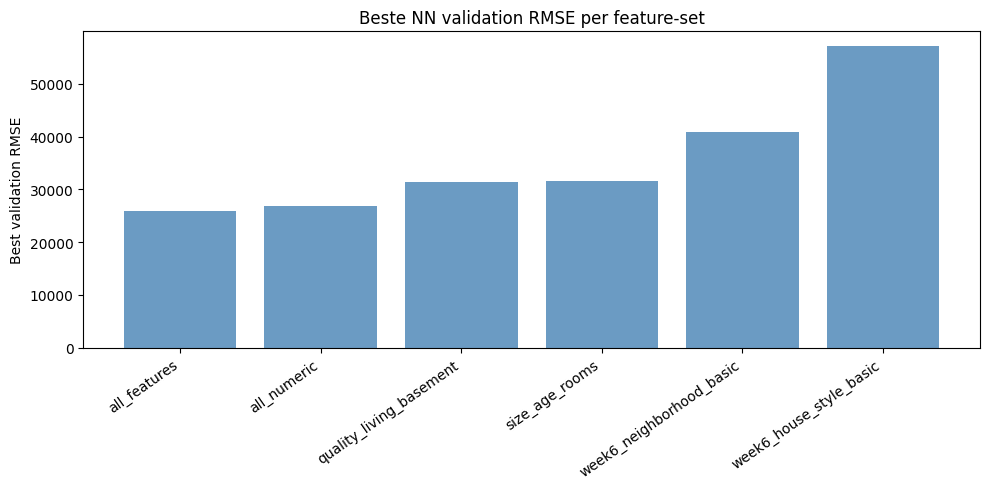

In [ ]:
# Bar chart: best validation RMSE per feature-set (lower is better)
plt.figure(figsize=(10, 5))
plot_df = feature_summary.sort_values("best_val_rmse")
plt.bar(plot_df["feature_set"], plot_df["best_val_rmse"], color="steelblue", alpha=0.8)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Best validation RMSE")
plt.title("Beste NN validation RMSE per feature-set")
plt.tight_layout()
plt.show()


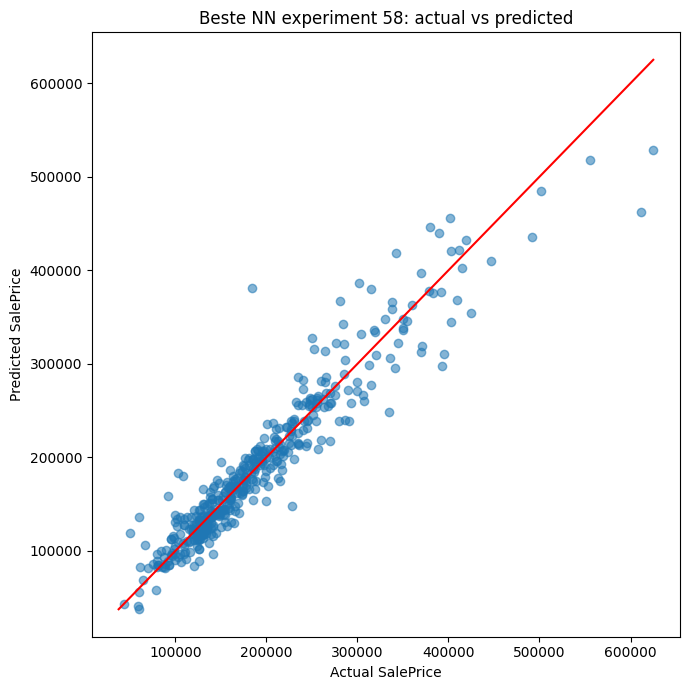

,Actual SalePrice,Predicted SalePrice
0,161000,156284.651510
1,116000,99141.477999
2,196500,173708.080185
3,123600,116067.480191
4,126000,89590.904588
5,174190,192140.717848
6,200000,153845.744516
7,148500,142839.904423
8,88750,85742.242290
9,409900,368203.714667


In [ ]:
# Retrieve the best experiment and its test predictions
best_experiment_id = int(best_by_validation["experiment_id"])
best_run = next(run for run in trained_runs if run["row"]["experiment_id"] == best_experiment_id)

# Build a DataFrame with actual vs predicted SalePrice
prediction_df = pd.DataFrame({
    "Actual SalePrice": best_run["y_test"].values,
    "Predicted SalePrice": best_run["test_pred"],
})

# Scatter plot: points close to the red diagonal line mean accurate predictions
plt.figure(figsize=(7, 7))
plt.scatter(prediction_df["Actual SalePrice"], prediction_df["Predicted SalePrice"], alpha=0.55)
min_value = min(prediction_df.min())
max_value = max(prediction_df.max())
plt.plot([min_value, max_value], [min_value, max_value], color="red")  # perfect prediction line
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title(f"Beste NN experiment {best_experiment_id}: actual vs predicted")
plt.tight_layout()
plt.show()

display(prediction_df.head(10))


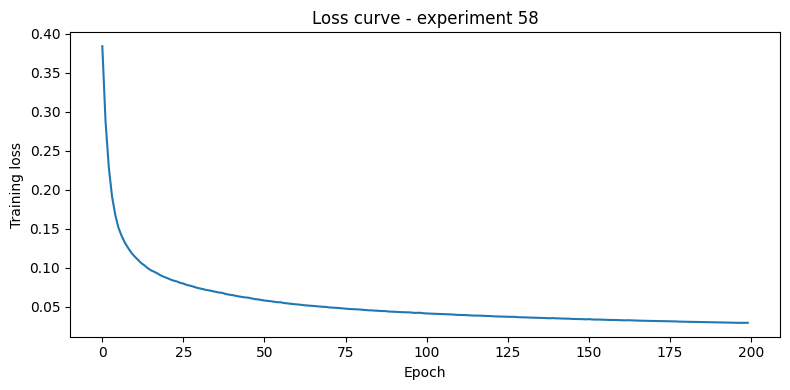

In [ ]:
# Loss curve: shows how the training error decreased over epochs.
# A curve that flattens early may indicate the model converged; one still falling may need more epochs.
loss_curve = best_run["loss_curve"]

plt.figure(figsize=(8, 4))
plt.plot(loss_curve)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title(f"Loss curve - experiment {best_experiment_id}")
plt.tight_layout()
plt.show()


## 7. Automatisch Excel-logboek exporteren

Na het draaien van de notebook wordt `experiment_log.xlsx` gevuld met alle experimenten, best-per-feature en voorspellingen van het beste model.


In [ ]:
# Export all results to Excel for further analysis outside the notebook
with pd.ExcelWriter(LOG_FILE, engine="openpyxl") as writer:
    results_df.to_excel(writer, sheet_name="NN experiments", index=False)    # all 60 experiments
    feature_summary.to_excel(writer, sheet_name="Best per feature", index=False)  # best per feature-set
    prediction_df.to_excel(writer, sheet_name="Best predictions", index=False)    # actual vs predicted

print(f"Excel-logboek opgeslagen als: {LOG_FILE.resolve()}")


Excel-logboek opgeslagen als: D:\User\Documents\Developments\Softwares\Python\HHS_Study\DEAI\WEEK 11\Practicum 3\experiment_log.xlsx


## 8. Conclusie invullen

Vul dit stuk aan nadat je de notebook hebt gedraaid.

Voorbeeldvragen:

- Welke feature-set had de laagste validation RMSE?
- Was `all_features` echt beter dan de subsets?
- Welke learning rate werkte het best?
- Ging een model met 3 hidden layers beter of juist slechter?
- Welke validation size gaf de stabielste resultaten?
